### Purpose
Given a Pauli string $p$ what is the shortest path to get it to be "implementable" (defined as a Pauli String with a Pauli weight of 1 and the single qubit operation being Z)?
This is important to understand because solving this problem will create a subroutine for solving the shortest distance problem for a Pauli word $P = [p_{1}, p_{2}, ... p_{n}]$

To solve this first, we shall find the shortest path in a graph of Pauli strings from an arbitrary Pauli string to an implementable Pauli string. The total number of possible nodes is on the scale of $4^{n + 1/2}$( the $1/2$ is to account for both positive and negative signs). Based on how, the paths form, an optimal or near optimal procedure can be made. 

In [6]:
import networkx as nx
import numpy as np 
import random as rnd

In [8]:
# class that implements tableau and necessary operations
# Reference -Improved Simulation of Stabilizer Circuits by Scott Aaronson & Daniel Gottesman
class Cirq_Tableau:
    
    def __init__(
        self,
        pauli_word: list[str] = None  
    ):
        if pauli_word is None or len(pauli_word) == 0:
            self._column_num = None
            self._row_num = None

            self._ss, self._xs, self._zs = None, None, None
        else:
            if "-" in pauli_word[0]:
                self._column_num = len(pauli_word[0][1:]) 
            else:
                self._column_num = len(pauli_word[0])
            self._row_num = len(pauli_word)

            self._ss = self.create_sign(pauli_word)
            self._xs, self._zs = self.create_tab(pauli_word)

    # setters & getters 
    @property
    def ss(self) -> np.ndarray:
        return self._ss

    @ss.setter 
    def ss(self, new_ss: np.ndarray):
        self._ss = new_ss
        
    @property
    def xs(self) -> np.ndarray:
        return self._xs

    @xs.setter 
    def xs(self, new_xs: np.ndarray):
        self._xs = new_xs
        
    @property
    def zs(self) -> np.ndarray:
        return self._zs

    @zs.setter 
    def zs(self, new_zs: np.ndarray):
        self._zs = new_zs
        
    @property
    def column_num(self) -> int:
        return self._column_num

    @column_num.setter 
    def column_num(self, new_num: int):
        self._column_num = new_num
    
    @property
    def row_num(self) -> int:
        return self._row_num

    @row_num.setter 
    def row_num(self, new_num: int):
        self._row_num = new_num

    # functions that create parts of tableau
    def create_sign(self, pauli_word: list[str]):
        temp_ss = np.zeros((self.row_num), dtype=int)
        for pauli_string in pauli_word:
            if "-" in pauli_string:
                index = pauli_word.index(pauli_string)
                pauli_word[index] = pauli_string.replace("-", "")
                #print(pauli_word)
                temp_ss[index] = 1
        return temp_ss
        
    def create_tab(self, pauli_word: list[str]):
        temp_x = np.zeros((self.row_num, self.column_num), dtype=int)
        temp_z = np.zeros((self.row_num, self.column_num), dtype=int)
        for i, pauli_string in enumerate(pauli_word):
            for j, pauli in enumerate(pauli_string):
                if pauli == "X" or pauli == "Y":
                    temp_x[i][j] = 1
                if pauli == "Z" or pauli == "Y":
                    temp_z[i][j] = 1
        return temp_x, temp_z

    # Clifford operations on tableau. 
    def apply_H(self,column: int):
        self.ss ^= self.xs[:, column] & self.zs[:, column]
        self.xs[:, column], self.zs[:, column] = self.zs[:, column].copy(), self.xs[:, column].copy()

    def apply_S(self, column: int):
        self.ss ^= self.xs[:, column] & self.zs[:, column]
        self.zs[:, column] = self.xs[:, column] ^ self.zs[:, column]

    def apply_CX(self, control: int, target: int):
        self.ss ^= (
            (self.xs[:, control] & self.zs[:, target])
            &(~(self.xs[:, target] ^ self.zs[:, control]))
        )
        self.xs[:, target] ^= self.xs[:, control]
        self.zs[:, control] ^= self.zs[:, target]

    # class operations necessary for comparisons and equating
    def copy(self):
        new_tab = Cirq_Tableau()
        new_tab.column_num = self.column_num
        new_tab.row_num = self.row_num
        new_tab.ss = self.ss.copy()
        new_tab.zs = self.zs.copy()
        new_tab.xs = self.xs.copy()
        return new_tab
    
    def __eq__(self, other):
        if not isinstance(other, type(self)):
            return NotImplemented  
        return (
            self.column_num == other.column_num
            and self.row_num == other.row_num
            and np.array_equal(self.ss, other.ss)
            and np.array_equal(self.xs, other.xs)
            and np.array_equal(self.zs, other.zs)
        )
    
    def return_string(self):
        string = ''
        for i in range(self.row_num):
            if self.ss[i]:
                string += "-"  

            for j in range(self.column_num):
                if self.xs[i][j] and not self.zs[i][j]:
                    string += "X"
                elif not self.xs[i][j] and self.zs[i][j]:
                    string += "Z"
                elif self.xs[i][j] and self.zs[i][j]:
                    string += "Y"
                else:
                    string += "I"
            if i < self.row_num - 1:
                string += "\n" 

        return string
    
    def __copy__(self):
        return self.copy()
        

    def __str__(self) -> str:
        ss = np.expand_dims(self.ss, axis = 1)
        xz = np.concatenate((self.xs, self.zs, ss), axis=1)
        return str(xz)

    def __hash__(self) -> int:
        return hash(self.zs.tobytes() + self.xs.tobytes() + self.ss.tobytes())

    def __lt__(self, other):
        return self.row_num < other.row_num

In [36]:
def graph_creator(init: str, digraph):
    '''
    Function to create a full graph of all the possible Pauli strings

    :param init: initial Pauli string to grow the graph from
    :param digraph: networkX graph to populate
    '''
    open_list = [init]
    closed_list = []

    while open_list:
        node = open_list[0]
        tableau = Cirq_Tableau(node.split("\n"))
        closed_list.append(node)
        del open_list[0]
        num_qubits = tableau.column_num
        for i in range(num_qubits):
            if i != (num_qubits - 1):
                for j in range((i+1), num_qubits):
                    tab1, tab2 = tableau.copy(), tableau.copy()
                    tab1.apply_CX(i, j)
                    tab2.apply_CX(j, i)
                    next_node1, next_node2 = tab1.return_string(), tab2.return_string()
                    digraph.add_edge(node, next_node1, weight =1, label=("CX", i, j))
                    digraph.add_edge(node, next_node2, weight =1, label=("CX", j, i))
                    if next_node1 not in closed_list:
                        open_list.append(next_node1)
                    if next_node2 not in closed_list:
                        open_list.append(next_node2)
                    
            tab3, tab4 = tableau.copy(), tableau.copy()
            tab3.apply_S(i)
            tab4.apply_H(i)
            next_node3, next_node4 = tab3.return_string(), tab4.return_string()
            digraph.add_edge(node, next_node3, weight =0, label=("S", i))
            digraph.add_edge(node, next_node4, weight =0, label=("H", i))
            if next_node3 not in closed_list:
                open_list.append(next_node3)
            if next_node4 not in closed_list:
                open_list.append(next_node4)

In [10]:
G = nx.DiGraph()
graph_creator("XX", G)

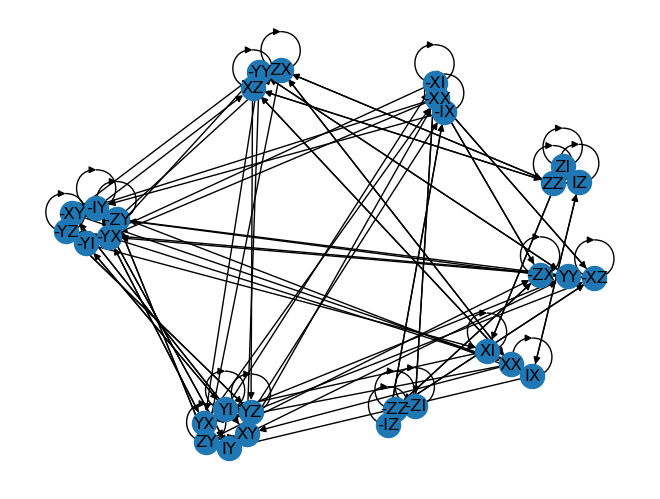

In [11]:
pos = layout=nx.spring_layout(G, scale=10)
nx.draw(G, with_labels=True)

In [12]:
DG = nx.DiGraph()
graph_creator("XXXX", DG)

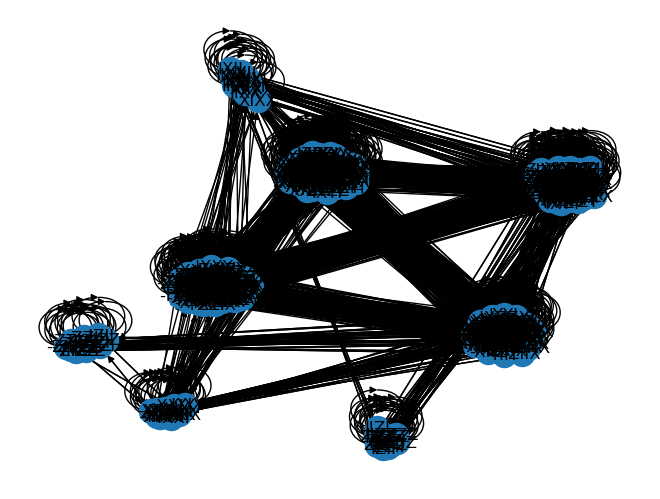

In [13]:
pos = layout=nx.spring_layout(DG, scale=10)
nx.draw(DG, pos, with_labels=True)

In [14]:
len(DG.nodes())

510

In [15]:
random_pauli = rnd.sample(list(DG.nodes()), 20)
random_pauli

['ZXYI',
 'IYYZ',
 '-XYXY',
 'YIXI',
 'XIZX',
 'YYII',
 '-ZIXI',
 'ZYIZ',
 '-ZZYX',
 '-ZYXX',
 '-XYZI',
 '-IZII',
 'YZYY',
 '-XXZX',
 '-XXXX',
 'XIXY',
 '-YIXX',
 'YXYI',
 '-XYZZ',
 '-YIIY']

In [16]:
targets = [
    "IIIZ",
    "IIZI",
    "IZII",
    "ZIII",
    "-IIIZ",
    "-IIZI",
    "-IZII",
    "-ZIII"
]

In [17]:
for pauli in random_pauli:
    print(f"paths from {pauli}")
    for end in targets:
        operations = []
        path = nx.shortest_path(DG, source=pauli, target=end, weight='weight')
        print(path)
        for i in range(len(path)-1):
            operations.append(DG[path[i]][path[i+1]]['label'])
        print(operations)
        print(f"Number of CNOTs {nx.path_weight(DG, path, 'weight')}")
        print()
    print()    

paths from ZXYI
['ZXYI', 'IXYI', 'IIYI', 'IIYX', '-IIXX', '-IIIX', '-IIIY', 'IIIX', 'IIIZ']
[('CX', 0, 2), ('CX', 2, 1), ('CX', 2, 3), ('S', 2), ('CX', 3, 2), ('S', 3), ('S', 3), ('H', 3)]
Number of CNOTs 4

['ZXYI', 'XXYI', 'XIYI', 'IIYI', '-IIYI', 'IIXI', 'IIZI']
[('H', 0), ('CX', 2, 1), ('CX', 2, 0), ('H', 2), ('S', 2), ('H', 2)]
Number of CNOTs 2

['ZXYI', 'XXYI', '-XXXI', '-IXXI', '-IXII', '-IYII', 'IXII', 'IZII']
[('H', 0), ('S', 2), ('CX', 2, 0), ('CX', 1, 2), ('S', 1), ('S', 1), ('H', 1)]
Number of CNOTs 2

['ZXYI', 'XXYI', '-XXXI', '-XIXI', '-XIII', '-YIII', 'XIII', 'ZIII']
[('H', 0), ('S', 2), ('CX', 2, 1), ('CX', 0, 2), ('S', 0), ('S', 0), ('H', 0)]
Number of CNOTs 2

['ZXYI', 'IXYI', 'IIYI', 'IIYX', '-IIXX', '-IIIX', '-IIIZ']
[('CX', 0, 2), ('CX', 2, 1), ('CX', 2, 3), ('S', 2), ('CX', 3, 2), ('H', 3)]
Number of CNOTs 4

['ZXYI', 'XXYI', 'XIYI', 'IIYI', '-IIXI', '-IIZI']
[('H', 0), ('CX', 2, 1), ('CX', 2, 0), ('S', 2), ('H', 2)]
Number of CNOTs 2

['ZXYI', '-ZXXI', '-ZXII', 

The work above has shown that the amount of minimum CNOTs necessary to get an arbitrary Pauli String to being implementable is its Pauli weight - 1. This makes sense because the CNOTs remove only one Pauli at a time when applied on a reducible pair _("XX", "ZY", "YX", "ZZ")_. For a 4 qubit Pauli String you would need to remove 3 Paulis which would require 3 CNOTs. The S and H gates simply permute single qubit Paulis and so can be used to produce the necessary reducible pairs. 

With this is mind the following steps can be taken:

Given a Pauli String:
* Apply CNOTs to reducible pairs
* If Pauli weight == 1 -> stop return new Pauli String and list of operations
* else -> convert first non X  Pauli to X with S or H, add operations to list and repeat

This works because it removes all the reducible pairs that exist in a Pauli string. There are only two situations where there will be no reducible pairs:

* The remainder of the Paulis are Ys
* There is one X and one Z left (if any other Pauli is present it will form a reducible pair with either the X or Z adn would be removed earlier)

Converting the first non X to X will introduce a reducible pair -> either _"XX"_ or _"YX"_. Though the number of Hs and Ss is not being tracked this way only uses one S or H gate to convert and only does so for the first non X encountered. This will prevent overuse of Hs and Ss when converting from Z to Y for example.  

In [30]:
def implementer(pauli_str: str):
    '''
    Function to convert a Pauli String to being implementable (Pauli weight of 1)

    :param pauli_str: string that represents a payli string
    '''

    # convert string into tableau because CX, H  and S operations are well defined in implementation
    tableau = Cirq_Tableau([pauli_str])

    # path to store operations done
    path = []

    # loop to continue until Pauli string is implementable 
    while True:

        # loop to apply CXs
        for i in range(tableau.column_num):
            if i != tableau.column_num -1:
                for j in range(i+1, tableau.column_num):
                    # conditions to check if Z Pauli is on control XOR X Pauli is on target and neither is I
                    if (~(tableau.xs[0][i]) & tableau.zs[0][i] & tableau.zs[0][j]) | (tableau.xs[0][i] & tableau.xs[0][j] & ~(tableau.zs[0][j])):
                        tableau.apply_CX(i,j)
                        path.append(("CX", i, j))
                    elif (~(tableau.xs[0][j]) & tableau.zs[0][j] & tableau.zs[0][i]) | (tableau.xs[0][j] & tableau.xs[0][i] & ~(tableau.zs[0][i])):
                        tableau.apply_CX(j, i)
                        path.append(("CX", j, i))
                        
        # Condition to check if Pauli String is implementable 
        if sum(tableau.xs[0] | tableau.zs[0]) == 1:
            implemented = np.where((tableau.xs[0] | tableau.zs[0]) == 1)[0].item()
            if (tableau.xs[0][implemented] & tableau.zs[0][implemented]):
                tableau.apply_S(implemented)
                path.append(("S",implemented))
                tableau.apply_H(implemented)
                path.append(("H",implemented))
            elif (tableau.xs[0][implemented] & ~(tableau.zs[0][implemented])):
                tableau.apply_H(implemented)
                path.append(("H",implemented))
            break

        # loop to change first Y or Z encountered to X
        for i in range(tableau.column_num):
            if (tableau.xs[0][i] & tableau.zs[0][i]):
                tableau.apply_S(i)
                path.append(("S",i))
                break
            elif (~(tableau.xs[0][i]) & tableau.zs[0][i]):
                tableau.apply_H(i)
                path.append(("H",i))
                break

    return path, tableau.return_string()

In [31]:
a= "ZYXZX"
path, string = implementer(a)
print(string, path)

-IZIII [('CX', 0, 1), ('CX', 1, 2), ('CX', 3, 1), ('CX', 1, 4), ('S', 1), ('H', 1)]


In [32]:
for pauli in random_pauli:
    path, string = implementer(pauli)
    print(f"path from {pauli} to {string}")
    print(path)
    print(f"Number of CNOTs {sum([1 for x in path if x[0] == "CX"])}")
    print()

path from ZXYI to -IIZI
[('CX', 0, 2), ('CX', 2, 1), ('S', 2), ('H', 2)]
Number of CNOTs 2

path from IYYZ to IIZI
[('CX', 3, 1), ('S', 1), ('CX', 2, 1), ('S', 2), ('H', 2)]
Number of CNOTs 2

path from -XYXY to -IIIZ
[('CX', 1, 0), ('CX', 1, 2), ('S', 1), ('CX', 3, 1), ('S', 3), ('H', 3)]
Number of CNOTs 3

path from YIXI to -ZIII
[('CX', 0, 2), ('S', 0), ('H', 0)]
Number of CNOTs 1

path from XIZX to ZIII
[('CX', 0, 3), ('H', 2), ('CX', 0, 2), ('H', 0)]
Number of CNOTs 2

path from YYII to IZII
[('S', 0), ('CX', 1, 0), ('S', 1), ('H', 1)]
Number of CNOTs 1

path from -ZIXI to -ZIII
[('H', 0), ('CX', 0, 2), ('H', 0)]
Number of CNOTs 1

path from ZYIZ to -IZII
[('CX', 0, 1), ('CX', 3, 1), ('S', 1), ('H', 1)]
Number of CNOTs 2

path from -ZZYX to IIZI
[('CX', 0, 1), ('CX', 1, 2), ('CX', 2, 3), ('S', 2), ('H', 2)]
Number of CNOTs 3

path from -ZYXX to IZII
[('CX', 0, 1), ('CX', 1, 2), ('CX', 1, 3), ('S', 1), ('H', 1)]
Number of CNOTs 3

path from -XYZI to IZII
[('CX', 1, 0), ('CX', 2, 1)

Now a simple test for a small Pauli word (2 qubits and two Pauli strings). The idea is to see if any information can be gleaned 

In [65]:
dG = nx.DiGraph()
graph_creator("XX\nXX", dG)

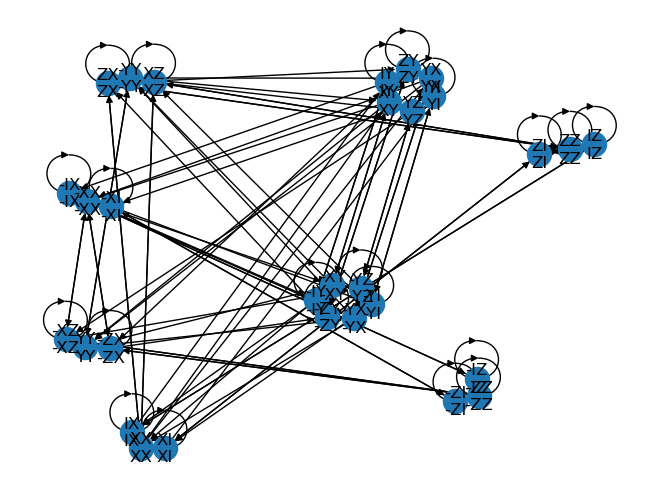

In [66]:
pos = layout=nx.spring_layout(dG, scale=10)
nx.draw(dG, pos, with_labels=True)

In [67]:
len(dG.nodes())

30

It seems like Pauli word graphs are separate from each other. They do not make one giant graph but rather make a graph dependent on how they are arranged. In this example it would be a Pauli word $P = [XX, XX]$ and the graph it lives in only has 30 accessible nodes - 8 of these accessible nodes have both Pauli strings as implementable. 

To get to a situation where both are implementable it is as simple as just applying a CNOT in whichever way to reduce both (this situation has both Pauli Strings being reducible in both directions)

Next attempt will be a Pauli word $P = [XX, YX]$ both YX and XX are reducible but XY is not reducible which increase the number of accessible states. 

In [59]:
DiG = nx.DiGraph()
graph_creator("XX\nYX", DiG)

In [61]:
len(DiG.nodes())

480

In [89]:
random_words = rnd.sample(list(DiG.nodes()), 20)
random_words

['-IZ\nIX',
 '-ZY\nIX',
 'XZ\n-IY',
 'XY\nYY',
 '-IY\n-YZ',
 'XZ\nIY',
 'YI\nXX',
 'YX\n-IZ',
 'IX\n-IY',
 'ZX\nZY',
 '-XZ\n-IX',
 '-XY\nZY',
 'ZX\n-ZZ',
 '-IY\nYZ',
 'XY\n-IZ',
 'YY\nZI',
 'ZY\nIX',
 '-IY\nXX',
 'ZY\n-XY',
 'IX\nXZ']

In [83]:
DiG.nodes()

NodeView(('XX\nYX', 'XI\nYI', 'IX\nZY', 'YX\n-XX', 'ZX\n-YX', 'XY\nYY', 'XZ\nYZ', 'XI\nYZ', 'YI\n-XI', 'ZI\n-YI', 'IX\nIY', 'IX\nXY', 'IY\n-ZX', 'IZ\n-ZY', 'ZY\n-IX', '-XX\n-YX', '-YX\n-ZX', 'YY\n-XY', 'YZ\n-XZ', 'ZX\n-YI', '-YY\n-ZY', 'ZX\nXX', 'ZY\n-YY', 'ZZ\n-YZ', '-XY\n-YY', '-YY\nXY', 'XZ\nYI', 'XX\nXY', 'YI\n-XZ', 'ZI\n-YZ', 'XI\nYX', 'YZ\n-XI', '-XI\n-YI', '-YI\n-ZI', 'ZI\n-YX', 'ZI\nXI', 'IY\n-IX', 'IZ\n-IY', 'IX\nYZ', 'XX\nIY', 'IX\nYY', 'IY\n-XX', 'IZ\n-XY', 'ZY\n-ZX', '-IX\n-ZY', '-IY\n-ZZ', 'ZZ\n-IY', 'IZ\n-YX', 'IZ\nZX', 'XY\n-IX', '-ZX\n-IY', '-ZY\n-IZ', '-YX\nXX', '-ZX\nYX', '-XZ\n-YZ', '-YI\n-ZX', '-ZY\nYY', 'XX\n-ZX', '-YZ\n-ZZ', '-YY\n-YZ', 'ZX\nXI', 'XX\nYI', 'ZY\n-YI', 'ZZ\n-YI', 'XZ\n-IY', 'XY\n-ZY', 'YX\nZX', 'YY\nZY', '-YY\nIX', 'ZX\nYX', 'XX\nZX', 'ZY\nXY', 'ZZ\nXZ', 'IY\nXZ', '-YZ\nXZ', '-IY\nZX', 'ZX\nIY', '-YY\nYX', 'YX\nYY', 'ZX\nZY', 'XY\n-XX', 'XZ\n-XY', '-XI\n-YZ', '-YI\n-ZZ', 'YI\n-XX', 'ZI\n-XY', 'ZI\nXZ', 'XI\nZY', 'XI\nYY', '-XZ\n-YI', '-YZ\n-ZI', 'YX

Next we try $P = [YZ, YX]$ because both YX and ZY can be reduced but they are not aligned with each other to reduce with the same CNOT

In [85]:
D = nx.DiGraph()
graph_creator("YZ\nYX", D)

In [87]:
len(D.nodes())

480

In [88]:
D.nodes()

NodeView(('YZ\nYX', 'XY\nYI', 'YI\nZY', '-XZ\n-XX', '-YZ\n-YX', 'YZ\nYY', 'YX\nYZ', 'IY\nYZ', 'YY\n-XI', 'ZY\n-YI', '-XX\nYI', '-XY\nYI', 'YX\nIY', '-XI\nZY', '-YI\nXY', 'YI\n-ZX', 'YI\n-ZY', '-XZ\n-IX', '-ZZ\n-ZX', '-XZ\n-XY', '-XX\n-XZ', '-XY\n-YI', '-YI\n-ZY', 'XZ\nXX', '-YZ\n-YY', '-YX\n-YZ', 'XY\n-XZ', 'YZ\n-YX', 'YX\n-YY', 'YI\nXY', 'ZY\nYI', 'YY\nYZ', 'ZY\nXY', 'IY\n-XZ', 'IY\n-YZ', '-IX\nYZ', '-IY\nYX', '-ZX\n-XI', '-YY\n-ZI', '-YX\n-XI', '-YY\n-XI', 'IY\n-YX', 'YX\n-YZ', 'ZY\nXI', '-ZX\n-YI', '-ZY\n-YI', '-XI\nYX', '-XZ\nYI', '-YZ\nYX', '-IY\nYZ', 'XX\nYI', '-XX\nIY', '-YX\nIY', 'YY\n-IX', 'YZ\n-IY', '-YI\nZY', '-ZI\nXY', '-XI\n-ZX', '-XI\n-ZY', '-YX\nYZ', '-YZ\nIY', 'XI\nYY', '-YI\n-XX', '-YI\n-XY', 'YX\n-ZX', 'YI\n-ZZ', 'YX\n-IY', 'YI\nZX', '-YZ\n-IX', '-ZZ\n-IX', '-XZ\n-IY', '-XX\n-IZ', '-IZ\n-ZX', '-ZI\nYY', '-ZZ\n-ZY', '-ZX\n-ZZ', 'YY\n-YZ', '-XZ\nXX', '-XX\nXY', '-XI\nYY', '-IX\n-XZ', '-XY\n-XZ', '-IY\n-YZ', '-YY\nXI', '-ZY\nYI', 'XX\n-YI', 'XY\n-YI', '-YX\n-IY', 'XI\n-Z

In [90]:
rnd.sample(list(D.nodes()), 20)

['IX\n-IY',
 'ZI\n-YY',
 '-YX\nYY',
 '-ZX\n-YI',
 '-YZ\n-IY',
 '-YI\nZI',
 '-IY\nIX',
 'YZ\nZZ',
 '-XI\nYX',
 'IX\nIZ',
 'XX\nYX',
 '-YI\nXY',
 'XI\nZI',
 '-XZ\nXY',
 '-YX\nYZ',
 'ZX\n-IZ',
 'ZI\nYY',
 '-YY\nZY',
 'ZX\nZY',
 '-IZ\nXX']